In [8]:
import os
import math
import warnings
from pathlib import Path
import random

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm


In [35]:
DATA_ROOT      = Path("./Data/training")
IMAGES_DIR     = DATA_ROOT / "Clean_Images"
TIMESERIES_DIR = DATA_ROOT / "Timeseries"
STRIPS_DIR     = DATA_ROOT / "Strips"
MASKS_DIR      = DATA_ROOT / "Masks"
CHUNKS_DIR     = DATA_ROOT / "Chunks"
CHECKPOINT_DIR = Path("./checkpoints")

BLACK_THRESHOLD     = 80
CAL_SPIKE_THRESHOLD = 25
LEFT_PCT            = 0.10
MIN_INTER_STRIP_GAP = 150
HEADER_GAP_RATIO    = 3.0
PADDING             = 20
COL_SPIKE_THRESHOLD = 50
MIN_CONSECUTIVE     = 5

Split points: [609, 1101, 1593]  (expected 3)


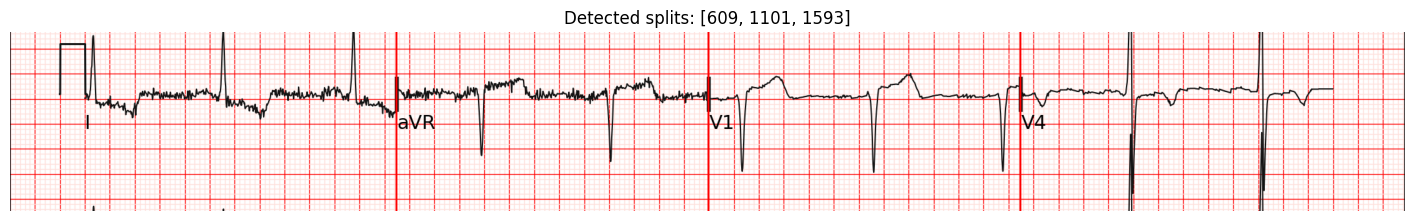

In [36]:
def find_split_points(strip):
    h, w = strip.shape[:2]
    b, g, r = cv2.split(strip)
    is_black = (r < BLACK_THRESHOLD) & (g < BLACK_THRESHOLD) & (b < BLACK_THRESHOLD)
    col_sums = is_black.sum(axis=0).astype(float)

    spike_cols = np.where(col_sums > 50)[0]

    # Group consecutive columns
    groups = []
    if len(spike_cols) > 0:
        group = [spike_cols[0]]
        for col in spike_cols[1:]:
            if col == group[-1] + 1:
                group.append(col)
            else:
                groups.append(group)
                group = [col]
        groups.append(group)

    # Filter obvious non-separators: borders, too narrow, too tall
    candidates = []
    for group in groups:
        width   = len(group)
        center  = int(np.mean(group))
        max_sum = col_sums[group].max()
        if width >= MIN_CONSECUTIVE and center > 10 and center < w - 10 and max_sum < 200:
            candidates.append((center, max_sum, width))

    if len(candidates) == 0:
        return []

    # We always expect 3 separators roughly evenly spaced at w/4, w/2, 3w/4
    # Score each candidate by how close it is to the expected positions
    expected = [w * 0.25, w * 0.50, w * 0.75]

    if len(candidates) >= 3:
        # Pick the best candidate for each expected position
        split_points = []
        used = set()
        for exp_x in expected:
            best = min(
                [c for i, c in enumerate(candidates) if i not in used],
                key=lambda c: abs(c[0] - exp_x)
            )
            idx = candidates.index(best)
            used.add(idx)
            split_points.append(best[0])
        return sorted(split_points)

    # Too few candidates — fall back to returning what we have
    return sorted([c[0] for c in candidates])

# Visual check
sample_strip_path = STRIPS_DIR / "3780045249_Clean_strip_1.png" #random.choice(sorted(STRIPS_DIR.glob("*_strip_1.png"))) this is an example of it not working
sample_strip      = cv2.imread(str(sample_strip_path))
split_points      = find_split_points(sample_strip)
print(f"Split points: {split_points}  (expected 3)")

vis = cv2.cvtColor(sample_strip, cv2.COLOR_BGR2RGB).copy()
for x in split_points:
    vis[:, max(0,x-1):x+2] = [255, 0, 0]

plt.figure(figsize=(18, 4))
plt.imshow(vis)
plt.title(f"Detected splits: {split_points}")
plt.axis("off")
plt.show()

In [37]:
def split_strip_into_chunks(strip_path, mask_path, output_dir):
    strip_idx = int(strip_path.stem.split("_strip_")[1])
    if strip_idx == 4:
        return [], None  #strip 4 doesn't have the different chunks

    strip = cv2.imread(str(strip_path))
    mask  = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    split_points = find_split_points(strip)

    if len(split_points) != 3:
        return None, f"Expected 3 split points, got {len(split_points)}"

    os.makedirs(output_dir, exist_ok=True)
    stem   = Path(strip_path).stem
    bounds = [0] + split_points + [strip.shape[1]]
    saved  = []
    for i in range(len(bounds) - 1):
        x1, x2   = bounds[i], bounds[i+1]
        chunk    = mask[:, x1:x2]
        out_path = Path(output_dir) / f"{stem}_chunk_{i+1}.png"
        cv2.imwrite(str(out_path), chunk)
        saved.append(str(out_path))

    return saved, None

# Run on all strips
CHUNKS_DIR.mkdir(parents=True, exist_ok=True)
strip_paths = sorted(STRIPS_DIR.glob("*.png"))
print(f"Found {len(strip_paths)} strips")

errors = []
total  = 0
for strip_path in tqdm(strip_paths, desc="Splitting chunks"):
    mask_path = MASKS_DIR / (strip_path.stem + "_mask.png")
    if not mask_path.exists():
        errors.append((strip_path.name, "mask not found"))
        continue
    saved, err = split_strip_into_chunks(strip_path, mask_path, CHUNKS_DIR)
    if err:
        errors.append((strip_path.name, err))
    else:
        total += len(saved)

print(f"\nSaved {total} chunks to {CHUNKS_DIR}")
print(f"Errors: {len(errors)}")
if errors:
    for name, err in errors[:10]:
        print(f"  {name}: {err}")

Found 2400 strips


Splitting chunks:   0%|          | 0/2400 [00:00<?, ?it/s]


Saved 7052 chunks to Data/training/Chunks
Errors: 37
  1006427285_Clean_strip_1.png: Expected 3 split points, got 0
  1436234058_Clean_strip_1.png: Expected 3 split points, got 0
  1492606769_Clean_strip_2.png: Expected 3 split points, got 2
  1512936796_Clean_strip_1.png: Expected 3 split points, got 0
  157249266_Clean_strip_2.png: Expected 3 split points, got 2
  1589810571_Clean_strip_1.png: Expected 3 split points, got 0
  1771293531_Clean_strip_1.png: Expected 3 split points, got 0
  1883137811_Clean_strip_1.png: Expected 3 split points, got 0
  2042532735_Clean_strip_1.png: Expected 3 split points, got 0
  2080106037_Clean_strip_1.png: Expected 3 split points, got 0


In [39]:
chunk_paths = sorted(CHUNKS_DIR.glob("*.png"))
print(f"Total chunks: {len(chunk_paths)}")

# Count successful records (those with all 12 chunks: 3 strips x 4 chunks)
from collections import defaultdict
record_chunks = defaultdict(int)
for cp in chunk_paths:
    # e.g. 32650710_Clean_strip_1_mask_chunk_1.png
    record_id = cp.stem.split("_Clean")[0]
    record_chunks[record_id] += 1

counts = pd.Series(record_chunks.values())
print(f"\nChunk count distribution per record:")
print(counts.value_counts().sort_index())
print(f"\nRecords with all 12 chunks: {(counts == 12).sum()}")
print(f"Total records: {len(record_chunks)}")

Total chunks: 7468

Chunk count distribution per record:
9      26
10      2
12    455
13     24
14     39
15     25
16     11
17      7
18      3
19      3
20      2
23      1
25      1
27      1
Name: count, dtype: int64

Records with all 12 chunks: 455
Total records: 600


In [201]:
COLOUR_CHUNKS_DIR = DATA_ROOT / "Colour_Chunks"
COLOUR_CHUNKS_DIR.mkdir(parents=True, exist_ok=True)

errors = []
total  = 0
for strip_path in tqdm(sorted(STRIPS_DIR.glob("*.png")), desc="Saving colour chunks"):
    strip_idx = int(strip_path.stem.split("_strip_")[1])
    if strip_idx == 4:
        continue

    strip        = cv2.imread(str(strip_path))
    split_points = find_split_points(strip)

    if len(split_points) != 3:
        errors.append((strip_path.name, f"got {len(split_points)} split points"))
        continue

    bounds = [0] + split_points + [strip.shape[1]]
    stem   = strip_path.stem
    for i in range(len(bounds) - 1):
        x1, x2   = bounds[i], bounds[i+1]
        chunk     = strip[:, x1:x2]
        out_path  = COLOUR_CHUNKS_DIR / f"{stem}_chunk_{i+1}.png"
        cv2.imwrite(str(out_path), chunk)
        total += 1

print(f"Saved {total} colour chunks")
print(f"Errors: {len(errors)}")

Saving colour chunks:   0%|          | 0/2400 [00:00<?, ?it/s]

Saved 7052 colour chunks
Errors: 37


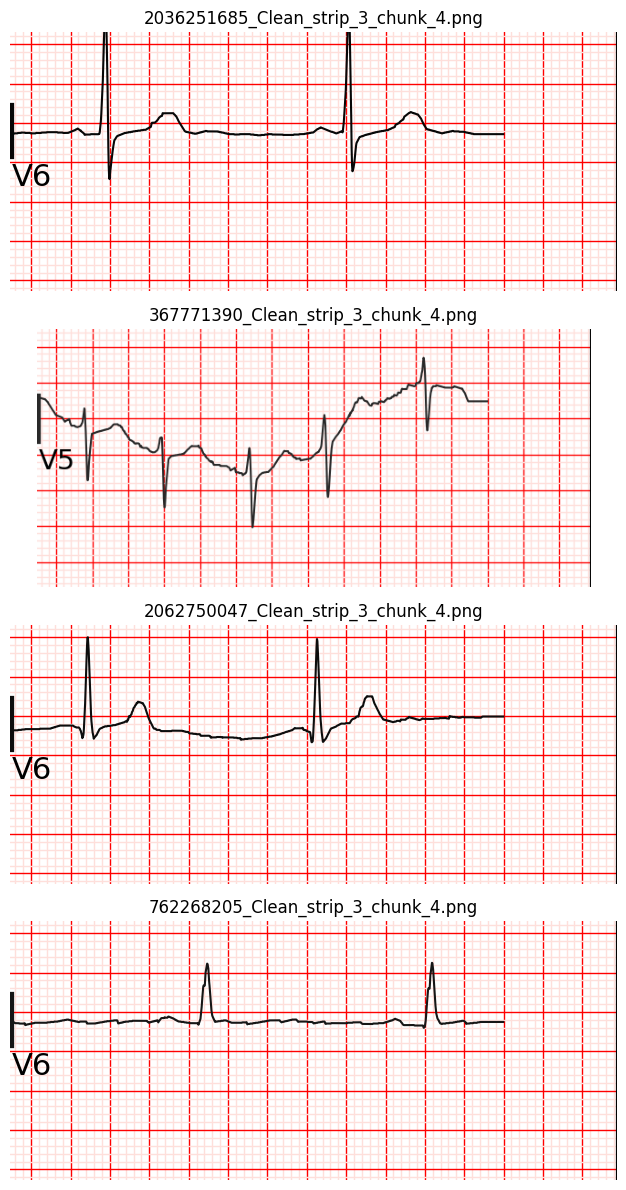

In [236]:
fig, axes = plt.subplots(4, 1, figsize=(18, 12))
samples = random.sample(sorted(list(COLOUR_CHUNKS_DIR.glob("*_strip_3_chunk_4.png"))), 4)
for i, cp in enumerate(samples):
    img = cv2.cvtColor(cv2.imread(str(cp)), cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(cp.name)
    axes[i].axis("off")
plt.tight_layout()
plt.show()

Found 2400 strips


Cropping chunks:   0%|          | 0/1763 [00:00<?, ?it/s]


Saved 1655 cropped chunks to Data/training/Colour_Chunks
Errors: 108
  1006427285_Clean_strip_2_chunk_1.png: Not enough spike cols
  1006427285_Clean_strip_3_chunk_1.png: Not enough spike cols
  1015663939_Clean_strip_1_chunk_1.png: Not enough spike cols
  1015663939_Clean_strip_2_chunk_1.png: Not enough spike cols
  1015663939_Clean_strip_3_chunk_1.png: Not enough spike cols
  1041099777_Clean_strip_1_chunk_1.png: Not enough spike cols
  1041099777_Clean_strip_2_chunk_1.png: Not enough spike cols
  1041099777_Clean_strip_3_chunk_1.png: Not enough spike cols
  1048962695_Clean_strip_1_chunk_1.png: Not enough spike cols
  1048962695_Clean_strip_2_chunk_1.png: Not enough spike cols


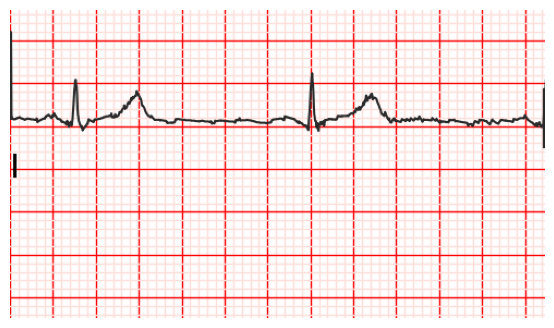

In [206]:
def crop_left_edge(chunk_path):
    strip_idx = int(chunk_path.stem.split("_")[-1])
    if strip_idx != 1:
        return None, "Not Left Chunk"  #we only do chunk 1
    
    chunk = cv2.imread(str(chunk_path))

    b, g, r = cv2.split(chunk)
    is_black = (r < BLACK_THRESHOLD) & (g < BLACK_THRESHOLD) & (b < BLACK_THRESHOLD)
    col_sums = is_black.sum(axis=0).astype(float)

    spike_cols = np.where(col_sums > 80)[0]
    if len(spike_cols) <= 3:
        return None, "Not enough spike cols"
    # if len(spike_cols) == 2:
    #     crop_point = spike_cols[1]
    #     print("Too few spike_cols")
    else:
        crop_point = spike_cols[3]

    
    cropped_chunk = chunk[:, crop_point:]
    cv2.imwrite(str(chunk_path), cropped_chunk)
    return(str(chunk_path), None)



# Run on all strips
chunk1s = sorted(COLOUR_CHUNKS_DIR.glob("*_chunk_1.png"))
print(f"Found {len(strip_paths)} strips")

errors = []
total  = 0
for strip_path in tqdm(chunk1s, desc="Cropping chunks"):
    saved, err = crop_left_edge(strip_path)
    if err:
        errors.append((strip_path.name, err))
    else:
        total += 1

print(f"\nSaved {total} cropped chunks to {COLOUR_CHUNKS_DIR}")
print(f"Errors: {len(errors)}")
if errors:
    for name, err in errors[:10]:
        print(f"  {name}: {err}")
# Visual check
sample_strip_path = random.choice(sorted(COLOUR_CHUNKS_DIR.glob("*_strip_1_chunk_1.png")))
sample_strip      = cv2.imread(str(sample_strip_path))
vis = cv2.cvtColor(sample_strip, cv2.COLOR_BGR2RGB).copy()


plt.figure(figsize=(18, 4))
plt.imshow(vis)
plt.axis("off")
plt.show()

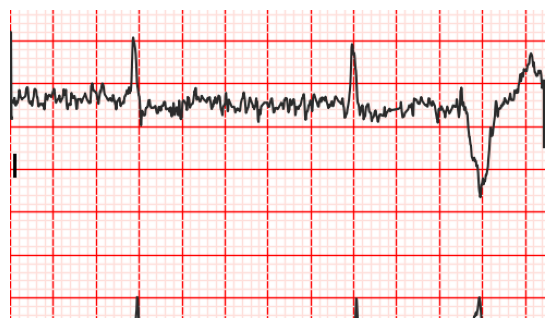

In [234]:
chunk_path = random.choice(sorted(COLOUR_CHUNKS_DIR.glob("*_strip_1_chunk_1.png")))



chunk = cv2.imread(str(chunk_path))



vis = cv2.cvtColor(chunk, cv2.COLOR_BGR2RGB).copy()



plt.figure(figsize=(18, 4))
plt.imshow(vis)
plt.axis("off")
plt.show()

Found 2400 strips


Cropping chunks:   0%|          | 0/1763 [00:00<?, ?it/s]

[[np.int64(494), np.int64(495), np.int64(496), np.int64(497), np.int64(498), np.int64(499), np.int64(500), np.int64(501), np.int64(502), np.int64(503), np.int64(504), np.int64(505), np.int64(506), np.int64(507), np.int64(508), np.int64(509), np.int64(510), np.int64(511), np.int64(512), np.int64(513), np.int64(514), np.int64(515), np.int64(516), np.int64(517), np.int64(518), np.int64(519), np.int64(520), np.int64(521), np.int64(522), np.int64(523), np.int64(524), np.int64(525), np.int64(526), np.int64(527), np.int64(528), np.int64(529), np.int64(530), np.int64(531), np.int64(532), np.int64(533), np.int64(534), np.int64(535), np.int64(536), np.int64(537), np.int64(538), np.int64(539), np.int64(540), np.int64(541), np.int64(542), np.int64(543), np.int64(544), np.int64(545), np.int64(546), np.int64(547), np.int64(548), np.int64(549), np.int64(550), np.int64(551), np.int64(552), np.int64(553), np.int64(554), np.int64(555), np.int64(556), np.int64(557), np.int64(558), np.int64(559), np.int64

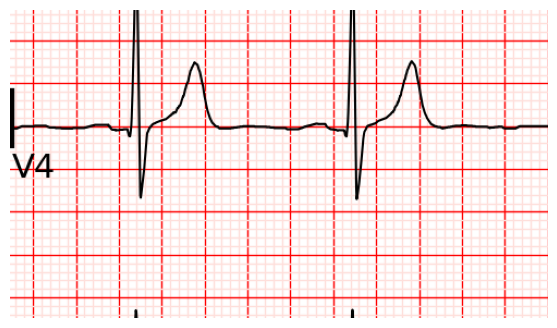

In [331]:
def crop_right_edge(chunk_path):
    strip_idx = int(chunk_path.stem.split("_")[-1])
    if strip_idx != 4:
        return None, "Not Right Chunk"  #we only do chunk 4
    
    chunk = cv2.imread(str(chunk_path))

    b, g, r = cv2.split(chunk)
    is_black = (r < BLACK_THRESHOLD) & (g < BLACK_THRESHOLD) & (b < BLACK_THRESHOLD)
    col_sums = is_black.sum(axis=0).astype(float)

    blank_cols = np.where(col_sums == 0)[0]

    # Group consecutive blank columns, looking for only groups with length at least 25
    groups = []
    if len(blank_cols) > 0:
        group = [blank_cols[0]]
        for col in blank_cols[1:]:
            if col == group[-1] + 1:
                group.append(col)
            else:
                if len(group) >= 25:
                    groups.append(group)
                group = [col]
        if len(group) >= 25:
            groups.append(group)
    
    #take the first value of the first group
    crop_point = groups[0][0]



    
    cropped_chunk = chunk[:, :crop_point]

    cv2.imwrite(str(chunk_path), cropped_chunk)
    return(str(chunk_path), None)


# Run on all strips
chunk4s = sorted(COLOUR_CHUNKS_DIR.glob("*_chunk_4.png"))
print(f"Found {len(strip_paths)} strips")

errors = []
total  = 0
for strip_path in tqdm(chunk4s, desc="Cropping chunks"):
    saved, err = crop_right_edge(strip_path)
    if err:
        errors.append((strip_path.name, err))
    else:
        total += 1

print(f"\nSaved {total} cropped chunks to {COLOUR_CHUNKS_DIR}")
print(f"Errors: {len(errors)}")
if errors:
    for name, err in errors[:10]:
        print(f"  {name}: {err}")
# Visual check
sample_strip_path = random.choice(sorted(COLOUR_CHUNKS_DIR.glob("*_strip_1_chunk_4.png")))
sample_strip      = cv2.imread(str(sample_strip_path))
vis = cv2.cvtColor(sample_strip, cv2.COLOR_BGR2RGB).copy()


plt.figure(figsize=(18, 4))
plt.imshow(vis)
plt.axis("off")
plt.show()